In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("C:/Users/a/Documents/Improvement/02-Learning/MACHINE_LEARNING/ml-from-scratch/datasets/auto+mpg/auto-mpg.data-original", sep=r"\s+")

In [4]:
data

,18.0,8.,307.0,130.0,3504.,12.0,70.,1.,chevrolet chevelle malibu
0,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
1,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
2,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
3,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino
4,15.0,8.0,429.0,198.0,4341.0,10.0,70.0,1.0,ford galaxie 500
...,...,...,...,...,...,...,...,...,...
400,27.0,4.0,140.0,86.0,2790.0,15.6,82.0,1.0,ford mustang gl
401,44.0,4.0,97.0,52.0,2130.0,24.6,82.0,2.0,vw pickup
402,32.0,4.0,135.0,84.0,2295.0,11.6,82.0,1.0,dodge rampage
403,28.0,4.0,120.0,79.0,2625.0,18.6,82.0,1.0,ford ranger


In [5]:
"""
    1. mpg:           continuous
    2. cylinders:     multi-valued discrete
    3. displacement:  continuous
    4. horsepower:    continuous
    5. weight:        continuous
    6. acceleration:  continuous
    7. model year:    multi-valued discrete
    8. origin:        multi-valued discrete
    9. car name:      string (unique for each instance)
"""

'\n    1. mpg:           continuous\n    2. cylinders:     multi-valued discrete\n    3. displacement:  continuous\n    4. horsepower:    continuous\n    5. weight:        continuous\n    6. acceleration:  continuous\n    7. model year:    multi-valued discrete\n    8. origin:        multi-valued discrete\n    9. car name:      string (unique for each instance)\n'

In [6]:
data.columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model year", "origin", "car name"]

In [7]:
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
1,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
2,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
3,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino
4,15.0,8.0,429.0,198.0,4341.0,10.0,70.0,1.0,ford galaxie 500
...,...,...,...,...,...,...,...,...,...
400,27.0,4.0,140.0,86.0,2790.0,15.6,82.0,1.0,ford mustang gl
401,44.0,4.0,97.0,52.0,2130.0,24.6,82.0,2.0,vw pickup
402,32.0,4.0,135.0,84.0,2295.0,11.6,82.0,1.0,dodge rampage
403,28.0,4.0,120.0,79.0,2625.0,18.6,82.0,1.0,ford ranger


In [8]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
1,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
2,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
3,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino
4,15.0,8.0,429.0,198.0,4341.0,10.0,70.0,1.0,ford galaxie 500


In [9]:
data["origin"].unique()

array([1., 2., 3.])

In [10]:
data["origin"] = data["origin"].map({
    1: "USA",
    2: "Europe",
    3: "Japan"
})

In [11]:
data = pd.get_dummies(data, columns = ["origin"], drop_first=True)

In [12]:
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,origin_Japan,origin_USA
0,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,buick skylark 320,False,True
1,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,plymouth satellite,False,True
2,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,amc rebel sst,False,True
3,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,ford torino,False,True
4,15.0,8.0,429.0,198.0,4341.0,10.0,70.0,ford galaxie 500,False,True
...,...,...,...,...,...,...,...,...,...,...
400,27.0,4.0,140.0,86.0,2790.0,15.6,82.0,ford mustang gl,False,True
401,44.0,4.0,97.0,52.0,2130.0,24.6,82.0,vw pickup,False,False
402,32.0,4.0,135.0,84.0,2295.0,11.6,82.0,dodge rampage,False,True
403,28.0,4.0,120.0,79.0,2625.0,18.6,82.0,ford ranger,False,True


In [13]:
data.isnull().sum()

mpg             8
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
car name        0
origin_Japan    0
origin_USA      0
dtype: int64

In [14]:
data["mpg"] = data["mpg"].fillna(data["mpg"].mean())

In [15]:
data["horsepower"] = data["horsepower"].fillna(data["horsepower"].mean())

In [16]:
data.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
car name        0
origin_Japan    0
origin_USA      0
dtype: int64

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           405 non-null    float64
 1   cylinders     405 non-null    float64
 2   displacement  405 non-null    float64
 3   horsepower    405 non-null    float64
 4   weight        405 non-null    float64
 5   acceleration  405 non-null    float64
 6   model year    405 non-null    float64
 7   car name      405 non-null    str    
 8   origin_Japan  405 non-null    bool   
 9   origin_USA    405 non-null    bool   
dtypes: bool(2), float64(7), str(1)
memory usage: 26.2 KB


In [18]:
data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,23.528463,5.469136,194.502469,105.020050,2978.118519,15.528395,75.935802
std,7.743104,1.709658,104.903397,38.508127,847.649260,2.801345,3.741767
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,105.000000,76.000000,2226.000000,13.700000,73.000000
50%,23.000000,4.000000,151.000000,95.000000,2815.000000,15.500000,76.000000
75%,29.000000,8.000000,302.000000,129.000000,3620.000000,17.200000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


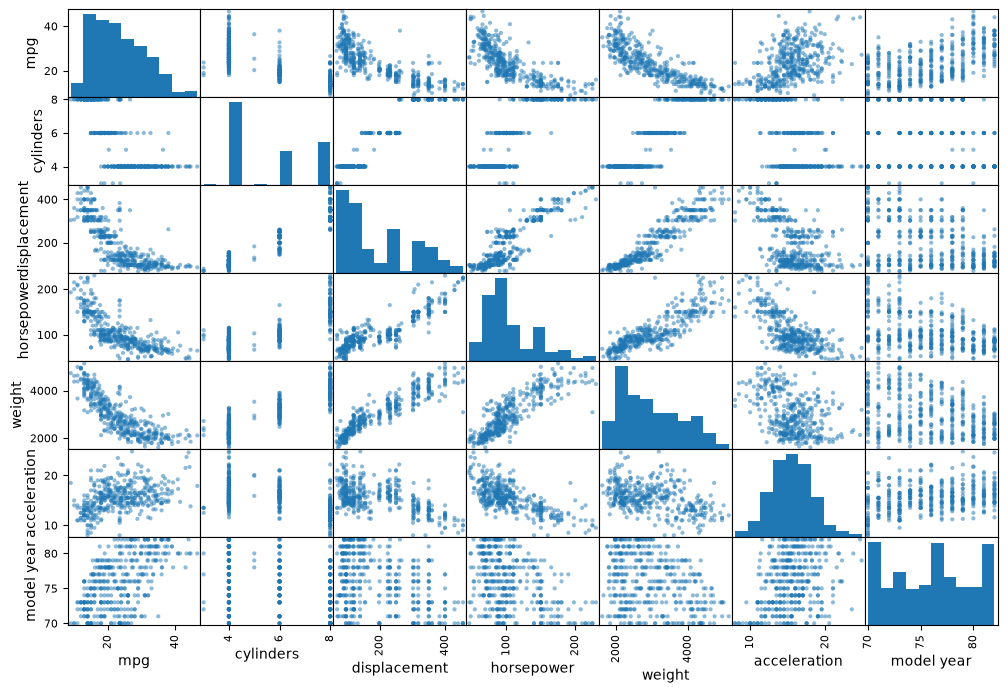

In [19]:
from pandas.plotting import scatter_matrix

cols = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model year"
]

scatter_matrix(data[cols], diagonal="hist", figsize=(12,8))
plt.show()

In [20]:
corr = data.select_dtypes(include="number").corr()

for i in cols:
    print(corr[i].sort_values())

weight         -0.823124
displacement   -0.790976
cylinders      -0.762609
horsepower     -0.757772
acceleration    0.408146
model year      0.564971
mpg             1.000000
Name: mpg, dtype: float64
mpg            -0.762609
acceleration   -0.520284
model year     -0.357060
horsepower      0.840492
weight          0.895798
displacement    0.951793
cylinders       1.000000
Name: cylinders, dtype: float64
mpg            -0.790976
acceleration   -0.556534
model year     -0.379241
horsepower      0.894751
weight          0.932598
cylinders       0.951793
displacement    1.000000
Name: displacement, dtype: float64
mpg            -0.757772
acceleration   -0.691987
model year     -0.418751
cylinders       0.840492
weight          0.862495
displacement    0.894751
horsepower      1.000000
Name: horsepower, dtype: float64
mpg            -0.823124
acceleration   -0.429203
model year     -0.314087
horsepower      0.862495
cylinders       0.895798
displacement    0.932598
weight          1.000000

In [21]:
X = data.drop(columns=['mpg', 'car name'])
y = data['mpg']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

,cylinders,displacement,horsepower,weight,acceleration,model year,origin_Japan,origin_USA
355,4.0,91.0,68.0,1985.0,16.0,81.0,True,False
234,6.0,250.0,98.0,3525.0,19.0,77.0,False,True
3,8.0,302.0,140.0,3449.0,10.5,70.0,False,True
18,8.0,455.0,225.0,3086.0,10.0,70.0,False,True
131,6.0,198.0,95.0,3102.0,16.5,74.0,False,True
...,...,...,...,...,...,...,...,...
71,8.0,351.0,153.0,4129.0,13.0,72.0,False,True
106,6.0,250.0,88.0,3021.0,16.5,73.0,False,True
270,8.0,302.0,139.0,3205.0,11.2,78.0,False,True
348,4.0,135.0,84.0,2385.0,12.9,81.0,False,True
